In [1]:
import os
import sys
import pandas as pd
import numpy as np
import missingno
import csv

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)

from utils import *

In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [3]:
base_path = f'../../data/{NUTS2}/results/'

In [4]:
file_list = os.listdir(base_path)
file_list.sort()
file_list

['GR_CMacedonia_Results_2010-2022.csv',
 'GR_CMacedonia_Results_2023-August-1st.csv',
 'GR_CMacedonia_Results_2023-July-1st.csv',
 'GR_CMacedonia_Results_2023-July-2nd.csv',
 'GR_CMacedonia_Results_2023-June-1st.csv',
 'GR_CMacedonia_Results_2023-June-2nd.csv',
 'GR_CMacedonia_Results_2023-May-1st.csv',
 'GR_CMacedonia_Results_2023-May-2nd.csv']

In [5]:
result_files = []

for file in file_list:
    data = pd.read_csv(f'{base_path}/{file}', encoding='utf-8')
    result_files.append(data)

In [6]:
#modifications

result_files[0].drop(columns=['x', 'y', 'case'], inplace=True)
result_files[0].rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)
result_files[1].drop(columns=['x', 'y', 'risk_class'], inplace=True)
result_files[2].drop(columns=['x', 'y', 'risk_class'], inplace=True)
result_files[3].drop(columns=['x', 'y', 'risk_class'], inplace=True)
result_files[4].drop(columns=['x', 'y', 'Class Number - (Relative Risk Level)', 'Class Number - (Risk Level)'], inplace=True)
result_files[4].rename(columns={"probability": "score"}, inplace=True)
result_files[5].drop(columns=['x', 'y', 'Class Number - (Relative Risk Level)', 'Class Number - (Risk Level)'], inplace=True)
result_files[5].rename(columns={"probability": "score"}, inplace=True)
result_files[6].drop(columns=['x', 'y', 'Class Number - (Relative Risk Level)', 'Class Number - (Risk Level)'], inplace=True)
result_files[6].rename(columns={"probability": "score"}, inplace=True)
result_files[7].drop(columns=['x', 'y', 'Class Number - (Relative Risk Level)', 'Class Number - (Risk Level)'], inplace=True)
result_files[7].rename(columns={"probability": "score"}, inplace=True)

In [7]:
concated = pd.concat(result_files, ignore_index=True, axis = 0)

<AxesSubplot:>

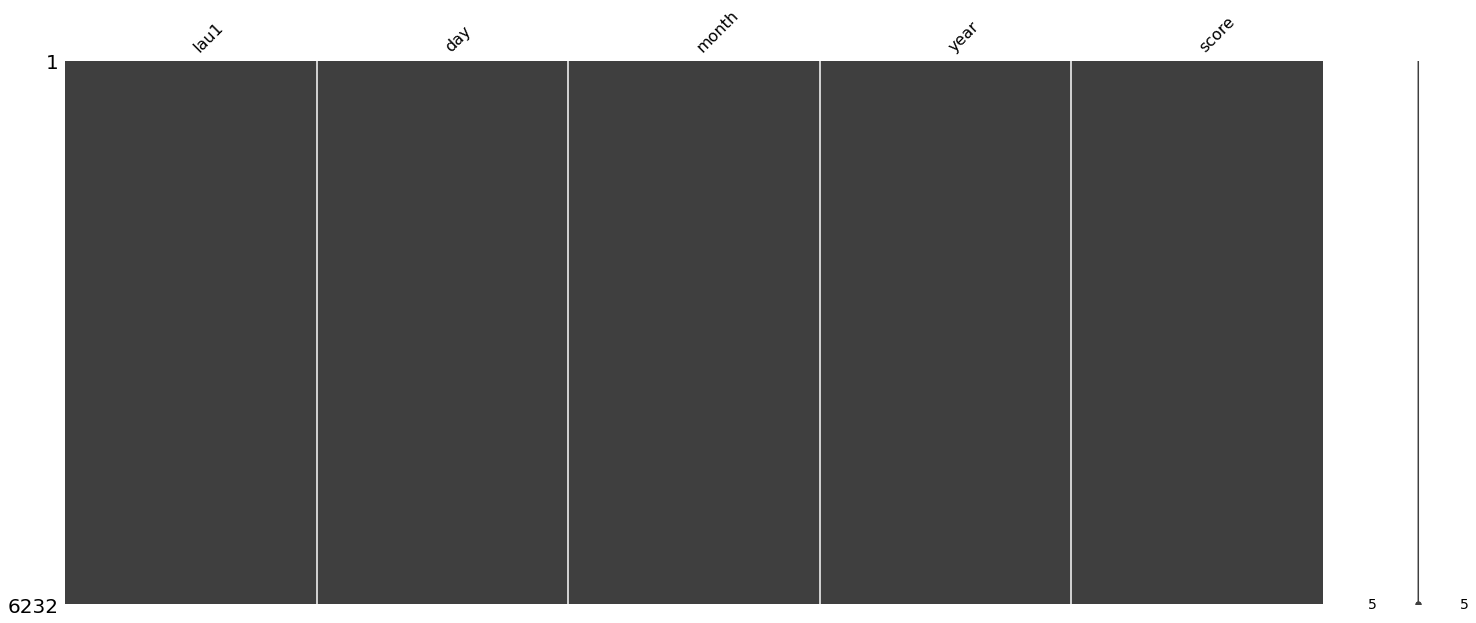

In [8]:
missingno.matrix(concated)

In [9]:
days = np.sort(concated.day.unique())
days

array([ 1, 16], dtype=int64)

In [10]:
months = np.sort(concated.month.unique())
months

array([ 5,  6,  7,  8,  9, 10, 11], dtype=int64)

In [11]:
years = np.sort(concated.year.unique())
years

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023], dtype=int64)

In [12]:
df = concated[(concated['month'] >= 5) & (concated['month'] <= 8)].copy()

In [13]:
condition = df[(df['month'] == 8) & (df['day'] == 16)].index
df.drop(condition, inplace = True)
df

,lau1,day,month,year,score
2,αλεξανδρειας,1,8,2021,0.988579
9,δελτα,1,8,2012,0.982610
13,θεσσαλονικης,1,8,2021,0.979550
14,αμπελοκηπων μενεμενης,1,8,2012,0.979199
17,κατερινης,1,8,2015,0.977510
...,...,...,...,...,...
6227,πυδνας κολινδρου,16,5,2023,0.001364
6228,νεαπολης συκεων,16,5,2023,0.001020
6229,πολυγυρου,16,5,2023,0.000984
6230,αριστοτελη,16,5,2023,0.000667


In [14]:
bins_path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Bins_2023.csv'

bins = []

with open(bins_path, mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        bins.extend(map(float, row))

print(bins)

[0.0, 0.0583897127083333, 0.3420709230240758, 0.6301540495738982, 0.7927550696593549, 0.8780877506216945, 0.9285101698085054, 0.9569216022382104, 0.9693090938355244, 0.9819432399118718, 1.0]


In [15]:
df['risk_class'] = pd.cut(df['score'], bins=bins, labels=False, include_lowest=True)
df.head(10)

,lau1,day,month,year,score,risk_class
2,αλεξανδρειας,1,8,2021,0.988579,9
9,δελτα,1,8,2012,0.982610,9
13,θεσσαλονικης,1,8,2021,0.979550,8
14,αμπελοκηπων μενεμενης,1,8,2012,0.979199,8
17,κατερινης,1,8,2015,0.977510,8
20,βεροιας,1,8,2022,0.976101,8
22,αμπελοκηπων μενεμενης,1,8,2018,0.973582,8
23,κατερινης,1,8,2022,0.973144,8
25,σκυδρας,1,8,2022,0.973015,8
29,σκυδρας,1,8,2015,0.972278,8


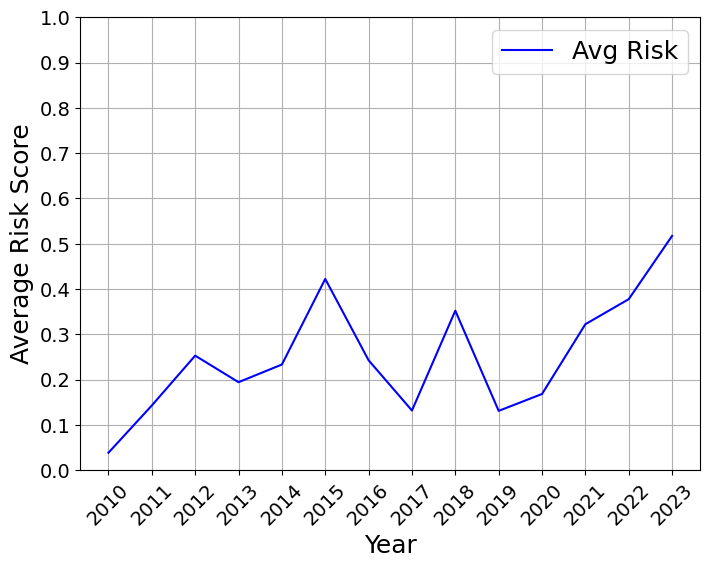

In [16]:
plot_trend_curve(df, plot_max = False, score_col = 'score', plot_cases=False, y_label='Average Risk Score')

In [17]:
risk_2022_over_7 = df[(df['year'] == 2022) & (df['risk_class'] >= 7)].copy()
risk_2022_over_7.reset_index(drop = True, inplace = True)
risk_2022_over_7

,lau1,day,month,year,score,risk_class
0,βεροιας,1,8,2022,0.976101,8
1,κατερινης,1,8,2022,0.973144,8
2,σκυδρας,1,8,2022,0.973015,8
3,βισαλτιας,1,8,2022,0.967508,7
4,κιλκις,1,8,2022,0.966120,7
5,ναουσας,1,8,2022,0.965612,7
6,πελλας,1,8,2022,0.962484,7
7,ηρακλειας,1,8,2022,0.962236,7
8,αλεξανδρειας,1,8,2022,0.957406,7


In [18]:
risk_2023_over_7 = df[(df['year'] == 2023) & (df['risk_class'] >= 7)].copy()
risk_2023_over_7.reset_index(drop = True, inplace = True)
risk_2023_over_7

,lau1,day,month,year,score,risk_class
0,πελλας,1,8,2023,0.997516,9
1,σκυδρας,1,8,2023,0.996263,9
2,κιλκις,1,8,2023,0.996076,9
3,αλεξανδρειας,1,8,2023,0.995905,9
4,ηρακλειας,1,8,2023,0.995708,9
...,...,...,...,...,...,...
81,θερμαϊκου,16,7,2023,0.976248,8
82,βισαλτιας,16,7,2023,0.975938,8
83,κορδελιου ευοσμου,16,7,2023,0.970450,8
84,εμμανουηλ παππα,16,7,2023,0.964975,7
